### 1: Load Cleaned Data

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/customer_churn_cleaned.csv")

df.head()

,Country,State,City,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
0,United States,California,Los Angeles,Male,No,No,No,2,Yes,No,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,3239
1,United States,California,Los Angeles,Female,No,No,Yes,2,Yes,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,2701
2,United States,California,Los Angeles,Female,No,No,Yes,8,Yes,Yes,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,5372
3,United States,California,Los Angeles,Female,No,Yes,Yes,28,Yes,Yes,...,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,5003
4,United States,California,Los Angeles,Male,No,No,Yes,49,Yes,Yes,...,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,5340


### 2: Understand the Target Variable

In [17]:
# Check the distribution of the target variable
df["Churn Value"].value_counts()

Churn Value
0    5163
1    1869
Name: count, dtype: int64

### Insight
 The dataset is moderately imbalanced, with approximately 26.6% of customers churning and 73.4% retained.

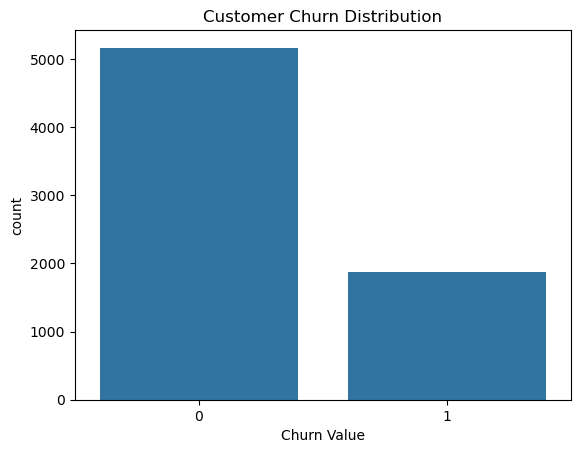

In [18]:
# Visualize the distribution of the target variable
sns.countplot(x="Churn Value", data=df)
plt.title("Customer Churn Distribution")
plt.savefig(
    "../images/customer_churn_distribution.png",
    bbox_inches="tight")
plt.show()

### 3: Numerical Features Analysis

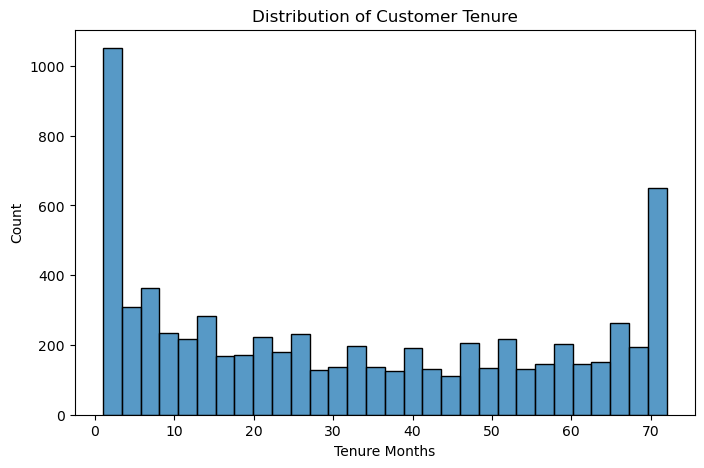

In [19]:
# Visualize the distribution of customer tenure
plt.figure(figsize=(8,5))
sns.histplot(df["Tenure Months"], bins=30)
plt.title("Distribution of Customer Tenure")
plt.savefig(
    "../images/tenure_distribution.png",
    bbox_inches="tight"
)
plt.show()

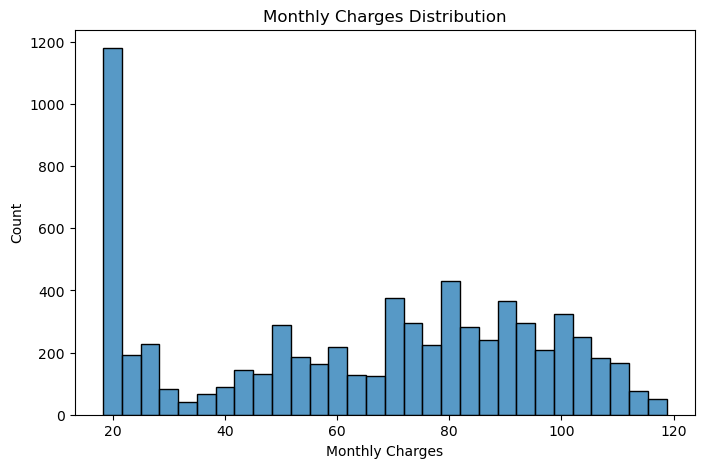

In [20]:
# Visualize the distribution of monthly charges
plt.figure(figsize=(8,5))
sns.histplot(df["Monthly Charges"], bins=30)
plt.title("Monthly Charges Distribution")
plt.savefig(
    "../images/monthly_charges_distribution.png",
    bbox_inches="tight"
)

plt.show()

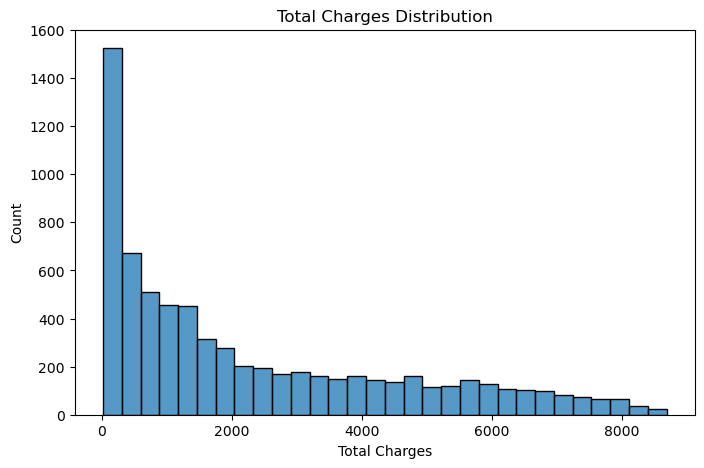

In [21]:
# Visualize the distribution of total charges
plt.figure(figsize=(8,5))
sns.histplot(df["Total Charges"], bins=30)
plt.title("Total Charges Distribution")
plt.savefig(
    "../images/total_charges_distribution.png",
    bbox_inches="tight"
)

plt.show()

### 4: Categorical vs Churn

In [22]:
# Gender vs Churn
pd.crosstab(
    df["Gender"],
    df["Churn Label"] if "Churn Label" in df.columns else df["Churn Value"]
)

Churn Value,0,1
Gender,,
Female,2544,939
Male,2619,930


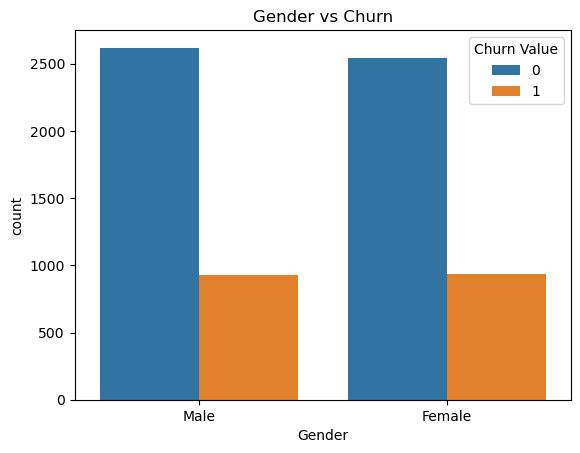

In [23]:
# Visualize the relationship between gender and churn
sns.countplot(
    x="Gender",
    hue="Churn Value",
    data=df
)
plt.title("Gender vs Churn")

plt.savefig(
    "../images/gender_vs_churn.png",
    bbox_inches="tight"
)

plt.show()

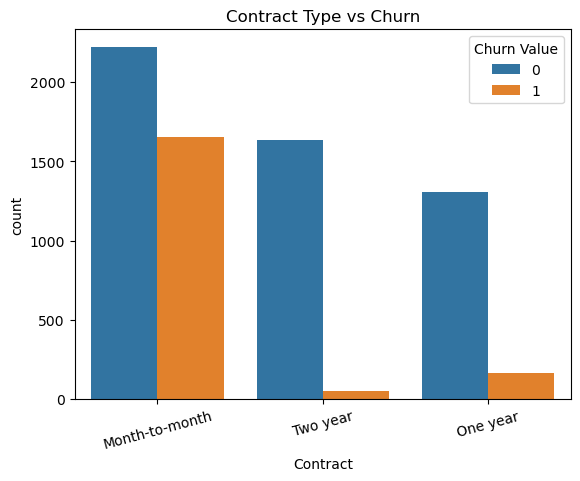

In [24]:
# Contract vs Churn
sns.countplot(
    x="Contract",
    hue="Churn Value",
    data=df
)

plt.xticks(rotation=15)
plt.title("Contract Type vs Churn")

plt.savefig(
    "../images/contract_vs_churn.png",
    bbox_inches="tight"
)

plt.show()

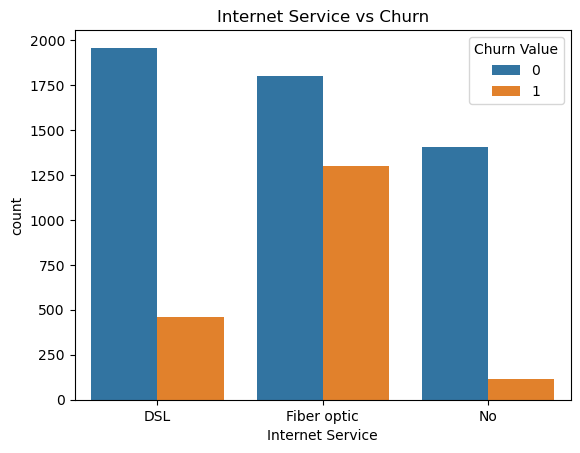

In [25]:
# Internet Service vs Churn
sns.countplot(
    x="Internet Service",
    hue="Churn Value",
    data=df
)
plt.title("Internet Service vs Churn")

plt.savefig(
    "../images/internet_service_vs_churn.png",
    bbox_inches="tight"
)

plt.show()

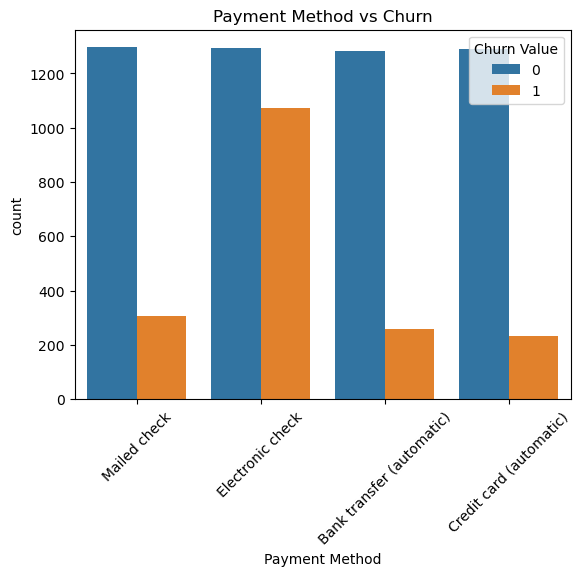

In [26]:
# Payment Method vs Churn
sns.countplot(
    x="Payment Method",
    hue="Churn Value",
    data=df
)

plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")

plt.savefig(
    "../images/payment_method_vs_churn.png",
    bbox_inches="tight"
)
plt.show()

### 5: Numerical Features vs Churn

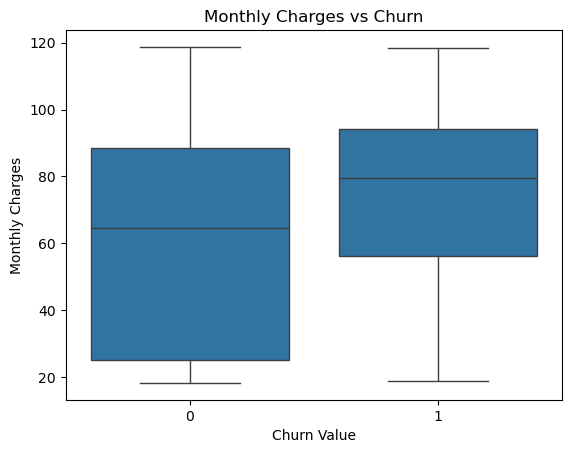

In [27]:
# Visualize the relationship between monthly charges and churn
sns.boxplot(
    x="Churn Value",
    y="Monthly Charges",
    data=df
)
plt.title("Monthly Charges vs Churn")

plt.savefig(
    "../images/monthly_charges_vs_churn_boxplot.png",
    bbox_inches="tight"
)

plt.show()

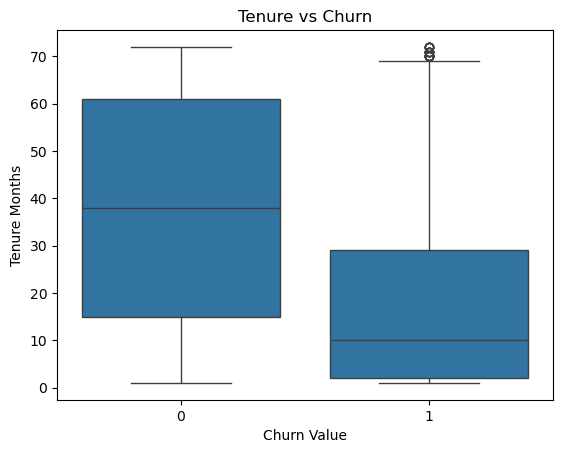

In [28]:
# Visualize the relationship between tenure months and churn
sns.boxplot(
    x="Churn Value",
    y="Tenure Months",
    data=df
)
plt.title("Tenure vs Churn")

plt.savefig(
    "../images/tenure_vs_churn_boxplot.png",
    bbox_inches="tight"
)

plt.show()

### 6: Correlation Analysis

In [29]:
# Correlation heatmap for numeric features
numeric_df = df.select_dtypes(include=np.number)

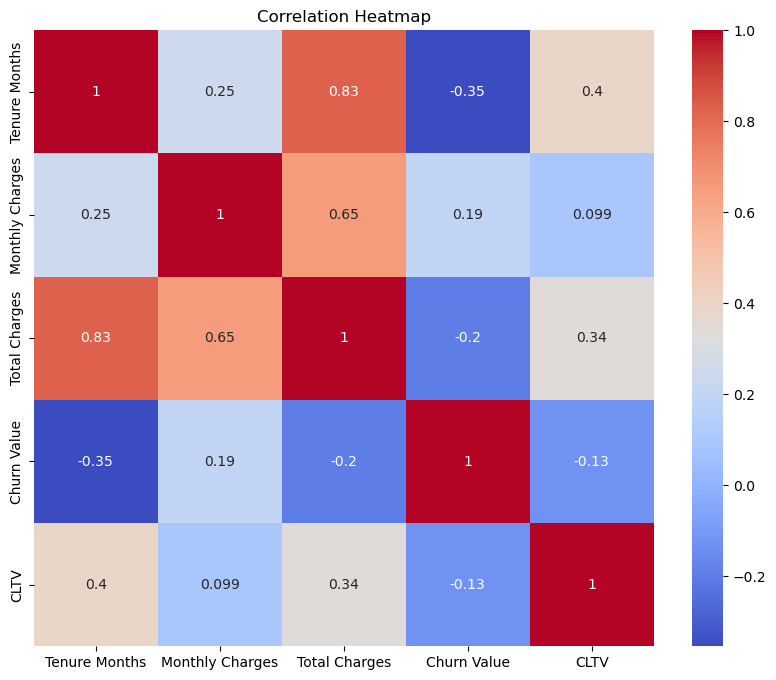

In [30]:
# Compute the correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")

plt.savefig(
    "../images/correlation_heatmap.png",
    bbox_inches="tight"
)
plt.show()

### 7: Key Business Insights

1. Approximately 26.6% of customers churned while 73.4% remained.
2. Customers with lower tenure are more likely to churn.
3. Customers paying higher monthly charges show higher churn tendencies.
4. Month-to-month contracts have the highest churn rate.
5. One-year and two-year contracts significantly improve retention.
6. Fiber optic customers churn more frequently than DSL customers.
7. Electronic check users have the highest churn rate among payment methods.
8. Gender has minimal impact on churn behavior.
9. Long-term customers generate higher total charges and exhibit stronger loyalty.